**References:**

- https://keras.io/examples/rl/ppo_cartpole/
- [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347)
- [OpenAI Spinning Up docs - PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html)
- [OpenAI Spinning Up Github - PPO](https://github.com/openai/spinningup/blob/master/spinup/algos/tf1/ppo/ppo.py)
- https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

In [ ]:
import warnings

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


import tensorflow as tf
#from tf import keras as keras
import keras
from keras import layers

import numpy as np
import gym
import scipy.signal

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle

In [ ]:
np.seterr(all="ignore")

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [ ]:
import matplotlib, cv2
import matplotlib.pyplot as plt
import base64, io, os, time
import IPython, functools
#from tqdm import tqdm
import tensorflow_probability as tfp
import math
from typing import Optional
from gym import spaces, logger
from gym.utils import seeding

In [ ]:
warnings.filterwarnings("ignore", message=".*Conversion of an array with ndim > 0 to a scalar.*")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from numpy.linalg import matrix_power
from scipy.linalg import block_diag

## Functions and class

In [ ]:
class CartPoleEnvCustomized(gym.Env):
    """
    ### Description
    This environment corresponds to the version of the cart-pole problem
    described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077).
    A pole is attached by an un-actuated joint to a cart, which moves along a
    frictionless track. The pendulum starts upright, and the goal is to prevent
    it from falling over by increasing and reducing the cart's velocity.
    ### Action Space
    The agent take a 1-element vector for actions.
    The action space is `(action)` in `[0, 1]`, where `action` is used to push
    the cart with a fixed amount of force:
    | Num | Action                 |
    |-----|------------------------|
    | 0   | Push cart to the left  |
    | 1   | Push cart to the right |
    Note: The amount the velocity is reduced or increased is not fixed as it depends on the angle the pole is pointing.
    This is because the center of gravity of the pole increases the amount of energy needed to move the cart underneath it
    ### Observation Space
    The observation is a `ndarray` with shape `(4,)` where the elements correspond to the following:
    | Num | Observation           | Min                  | Max                |
    |-----|-----------------------|----------------------|--------------------|
    | 0   | Cart Position         | -4.8*                 | 4.8*                |
    | 1   | Cart Velocity         | -Inf                 | Inf                |
    | 2   | Pole Angle            | ~ -0.418 rad (-24°)** | ~ 0.418 rad (24°)** |
    | 3   | Pole Angular Velocity | -Inf                 | Inf                |
    **Note:** above denotes the ranges of possible observations for each element, but in two cases this range exceeds the
    range of possible values in an un-terminated episode:
    - `*`: the cart x-position can be observed between `(-4.8, 4.8)`, but an episode terminates if the cart leaves the
    `(-2.4, 2.4)` range.
    - `**`: Similarly, the pole angle can be observed between  `(-.418, .418)` radians or precisely **±24°**, but an episode is
    terminated if the pole angle is outside the `(-.2095, .2095)` range or precisely **±12°**
    ### Rewards
    Reward is 1 for every step taken, including the termination step. The threshold is 475 for v1.
    ### Starting State
    All observations are assigned a uniform random value between (-0.05, 0.05)
    ### Episode Termination
    The episode terminates of one of the following occurs:
    1. Pole Angle is more than ±12°
    2. Cart Position is more than ±2.4 (center of the cart reaches the edge of the display)
    3. Episode length is greater than 500 (200 for v0)
    ### Arguments
    No additional arguments are currently supported.
    """

    metadata = {"render.modes": ["human", "rgb_array"], "video.frames_per_second": 50}

    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.dt = 0.02  # seconds between state updates
        self.kinematics_integrator = None # "euler","semi-implicit euler"


        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                self.theta_threshold_radians * 2,
                np.finfo(np.float32).max,
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.viewer = None
        self.state = None

        self.steps_beyond_done = None

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        self.NumIntegrationsSteps = 1
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60
        dt_prime = self.dt/self.NumIntegrationsSteps
        self.tau = dt_prime
        self.MPC.dt = dt_prime
        self.MPC.plant.tau1 = dt_prime
        self.MPC.ref_model.tau1 = dt_prime
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0

        self.ideal_env = False
        ####


    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg

        x, x_dot, theta, theta_dot = self.state
        force = +self.force_mag if action == 1 else -self.force_mag #+/-10N
        #wanted_torque_ret = self.wanted_torque #return old action
        torque_wanted = force*self.DCMotor_radius
        self.MPC.y_spf = torque_wanted
        beta_AF = 0.135#0.135#0.5
        torque_wanted =  (beta_AF)*self.wanted_torque+(1-beta_AF)*torque_wanted
        self.wanted_torque = torque_wanted
        self.MPC.y[0] = torque_wanted #self.MPC.y_spf #torque_wanted
        wanted_torque_ret = self.wanted_torque

        ### Customization changes #####
        for n in np.arange(start=0, stop=self.NumIntegrationsSteps, step=1):
            if self.ideal_env:
              torque_actual = torque_wanted
            else:
              self.MPC.plant.thetadot =  x_dot/self.DCMotor_radius
              torque_actual = self.MPC.step()
            F = torque_actual/self.DCMotor_radius
            #F = force #ideal env
            ###

            costheta = math.cos(theta)
            sintheta = math.sin(theta)

            # For the interested reader:
            # https://coneural.org/florian/papers/05_cart_pole.pdf
            temp = (
                F + self.polemass_length * theta_dot ** 2 * sintheta
            ) / self.total_mass
            thetaacc = (self.gravity * sintheta - costheta * temp) / (
                self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
            )
            xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

            if self.kinematics_integrator == "euler":
                x = x + self.tau * x_dot
                x_dot = x_dot + self.tau * xacc
                theta = theta + self.tau * theta_dot
                theta_dot = theta_dot + self.tau * thetaacc
            elif self.kinematics_integrator == "semi-implicit euler":
                x_dot = x_dot + self.tau * xacc
                x = x + self.tau * x_dot
                theta_dot = theta_dot + self.tau * thetaacc
                theta = theta + self.tau * theta_dot
            else: # trapz on velocities
                new_x_dot = x_dot + self.tau * xacc
                new_theta_dot = theta_dot + self.tau * thetaacc
                x = x + self.tau * (x_dot+new_x_dot)/2
                theta = theta + self.tau * (theta_dot+new_theta_dot)/2
                x_dot = new_x_dot+0
                theta_dot = new_theta_dot+0

        self.state = (x, x_dot, theta, theta_dot)

        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
        )

        if not done: # if we inside the valid range
            reward = 1.0

        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 1.0

        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0.0

        return np.array(self.state, dtype=np.float32), reward, done, {} ,wanted_torque_ret, torque_actual


    def reset(self, return_info = False, options = None):
        #super().reset(seed=seed)
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_done = None

        ### reset MPC
        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0
        #

        if not return_info:
            return np.array(self.state, dtype=np.float32)
        else:
            return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"):
        screen_width = 600
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        carty = 100  # TOP OF CART
        polewidth = 10.0
        polelen = scale * (2 * self.length)
        cartwidth = 50.0
        cartheight = 30.0

        if self.viewer is None:
            #from gym.utils import pyglet_rendering
            from gym.envs.classic_control import rendering as pyglet_rendering

            self.viewer = pyglet_rendering.Viewer(screen_width, screen_height)
            l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
            axleoffset = cartheight / 4.0
            cart = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            self.carttrans = pyglet_rendering.Transform()
            cart.add_attr(self.carttrans)
            self.viewer.add_geom(cart)
            l, r, t, b = (
                -polewidth / 2,
                polewidth / 2,
                polelen - polewidth / 2,
                -polewidth / 2,
            )
            pole = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            pole.set_color(0.8, 0.6, 0.4)
            self.poletrans = pyglet_rendering.Transform(translation=(0, axleoffset))
            pole.add_attr(self.poletrans)
            pole.add_attr(self.carttrans)
            self.viewer.add_geom(pole)
            self.axle = pyglet_rendering.make_circle(polewidth / 2)
            self.axle.add_attr(self.poletrans)
            self.axle.add_attr(self.carttrans)
            self.axle.set_color(0.5, 0.5, 0.8)
            self.viewer.add_geom(self.axle)
            self.track = pyglet_rendering.Line((0, carty), (screen_width, carty))
            self.track.set_color(0, 0, 0)
            self.viewer.add_geom(self.track)

            self._pole_geom = pole

        if self.state is None:
            return None

        # Edit the pole polygon vertex
        pole = self._pole_geom
        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )
        pole.v = [(l, b), (l, t), (r, t), (r, b)]

        x = self.state
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        self.carttrans.set_translation(cartx, carty)
        self.poletrans.set_rotation(-x[2])

        return self.viewer.render(return_rgb_array=mode == "rgb_array")

    def close(self):
        if self.viewer:
            self.viewer.close()
            self.viewer = None

In [ ]:
# High Fidelity Cartpole ENV by L. Bantel, et al (https://doi.org/10.1109/INTCEC61833.2024.10602859)
# https://github.com/SC-SGS/High-Fidelity-Cartpole
import math
from math import pi, cos, sin, trunc, e
from typing import Optional, Union
import gin

import numpy as np
import pygame
from pygame import gfxdraw

import gym
from gym import spaces, logger
from gym.utils import seeding

#@gin.configurable
class HighFidelityCartPoleEnvCustomized(gym.Env[np.ndarray, Union[int, np.ndarray]]):

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self,
                 force_steps = [0,2,5,7,10,15,20],#[0,5,10,15,20],# [0,100,150,200,250]
                 masscart = 0.94,
                 masspole = 0.1,
                 length = 0.1778,
                 force_mag = 3.0,
                 NumIntegrationsSteps = 1, #internal_tau = 0.02,
                 dt=0.02,#tau = 0.02,
                 x_threshold = 0.3,
                 pole_resistance = 0.99,
                 cart_resistance = 0.99,
                 force_curve = [0,1,0],
                 evaluation = False,#False,
                 swingup = False,#False,
                 discrete_state = False,
                 action_in_state = False): #action_in_state=True

        #set "evaluation" in the code to obtain a second environment for evaluation,
        #for conistent resets

        #physical parameters
        self.force_steps = force_steps
        self.gravity = 9.8
        self.masscart = masscart
        self.masspole = masspole
        self.total_mass = self.masspole + self.masscart
        self.length = length  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag_mean = force_mag
        self.force_mag = None
        self.dt = dt
        self.NumIntegrationsSteps = NumIntegrationsSteps
        self.internal_tau = dt/NumIntegrationsSteps #internal_tau # seconds for euler step
        #self.tau = tau  # seconds between state updates, multiple of internal tau
        self.mean_pole_resistance = e**(pole_resistance*self.internal_tau)
        self.mean_cart_resistance = cart_resistance
        self.cart_resistance = None
        self.pole_resistance = None
        self.force_curve = force_curve

        #different experimental setups
        self.evaluation = evaluation
        self.swingup = swingup
        self.action_in_state = action_in_state
        self.discrete_state = discrete_state

        self.states = []


        # Angle at which to fail the classical task
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = x_threshold

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                pi,
                np.finfo(np.float32).max
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(len(self.force_steps) * 2 - 1)


        #action within state
        if self.action_in_state:
            action = np.ones(len(force_steps)*2+1)
            self.observation_space = spaces.Box(np.concatenate((-high, action*0)), np.concatenate((high, action)), dtype=np.float32)
            print('action_in_state = True')
        else:
            self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.screen = None
        self.clock = None
        self.isopen = True
        self.state = None
        self.num_steps = None

        self.steps_beyond_done = None

        self.last_action = None
        self.last_reward = 0

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60
        #dt_prime = self.dt/self.NumIntegrationsSteps
        #self.tau = dt_prime
        self.MPC.dt = self.internal_tau
        self.MPC.plant.tau1 = self.internal_tau
        self.MPC.ref_model.tau1 = self.internal_tau
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0
        self.kinematics_integrator = None # "euler","semi-implicit euler"


        self.ideal_env = False
        ####



    def update_state(self, state, force, tau):
        #function implements the actual differential equation and integration

        x, x_dot, theta, theta_dot = state

        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf

        #sign function can lead to weird results depending on the time-step-width
        #possible replacement is a scaled and parameterized sigmoid

        temp = (
            force + self.polemass_length * theta_dot ** 2 * sintheta
            - self.cart_resistance*np.tanh(x_dot*tau)#sign(x_dot)
        ) / self.total_mass

        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
        )

        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass


        if self.kinematics_integrator == "euler":
          x = x + self.tau * x_dot
          x_dot = x_dot + tau * xacc
          theta = theta + tau * theta_dot
          theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
        elif self.kinematics_integrator == "semi-implicit euler":
          x_dot = x_dot + tau * xacc
          x = x + self.tau * x_dot
          theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
          theta = theta + tau * theta_dot
        else: # trapz on velocities
          new_x_dot = x_dot + tau * xacc
          new_theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
          x = x + tau * (x_dot+new_x_dot)/2
          theta = theta + tau * (theta_dot+new_theta_dot)/2
          x_dot = new_x_dot+0
          theta_dot = new_theta_dot+0

        theta = angle_normalize(theta)


        return (x, x_dot, theta, theta_dot)



    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg
        assert self.state is not None, "Call reset before using step method."


        action = action - len(self.force_steps) + 1



        if action > 0:
            dir = 1
        elif action < 0:
            dir = -1
        else:
            dir = 0


        #motor values to use (0-255)
        force = self.force_steps[abs(action)]


        #force curve of the cartpole
        force = self.force_curve[0]*force**2 - self.force_curve[1]*force +  self.force_curve[2]
        force *= dir
        torque_wanted=force*self.DCMotor_radius
        #wanted_torque_ret = self.wanted_torque #return old action
        self.MPC.y_spf = torque_wanted
        beta_AF = 0.5#0.5,0.135
        torque_wanted =  (beta_AF)*self.wanted_torque+(1-beta_AF)*torque_wanted
        self.wanted_torque = torque_wanted
        self.MPC.y[0] = torque_wanted #self.MPC.y_spf #torque_wanted
        wanted_torque_ret = self.wanted_torque

        # get current state
        x, x_dot, theta, theta_dot = self.state

        if self.discrete_state:
            old_disc_theta = discretize_angle(theta)


        #internal finer stepping of the simulation
        for i in range(self.NumIntegrationsSteps):
          if self.ideal_env:
            torque_actual = torque_wanted
          else:
            self.MPC.plant.thetadot =  x_dot/self.DCMotor_radius
            torque_actual = self.MPC.step()
          F = torque_actual/self.DCMotor_radius
          self.state = self.update_state(self.state, F, self.internal_tau)
          x, x_dot, theta, theta_dot = self.state



        x, x_dot, theta, theta_dot = self.state

        #calculating the derivatives of the discrete state for the output
        if self.discrete_state:
            new_disc_theta = discretize_angle(theta)

            if new_disc_theta > pi/2 and old_disc_theta < -pi/2:
                old_disc_theta += 2*pi
            elif new_disc_theta < -pi/2 and old_disc_theta > pi/2:
                old_disc_theta -= pi

            disc_theta_dot = (new_disc_theta - old_disc_theta)/self.dt
            out_state = (x, x_dot, new_disc_theta, disc_theta_dot)
        else:
            out_state = self.state


        #variable to check, if pole is upright
        if abs(theta) < self.theta_threshold_radians:
            self.swingup_done = True
        elif abs(theta) > self.theta_threshold_radians:
            self.swingup_done = False


        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or abs(theta_dot) > 5*pi
            or (abs(theta) > self.theta_threshold_radians and not self.swingup)
        )

        if not done:
            if self.evaluation:
                reward = cos(theta / 2) * (1-abs(x)/self.x_threshold)
            else:
                reward = cos(theta / 2) * (1-abs(x)/self.x_threshold)
            #additional addon for training swingup faster

            if self.swingup and abs(theta) < 5/180*pi:
                reward += 5
                if abs(theta_dot) < 6/180*pi:
                    reward += 5


        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 0
        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0


        self.num_steps += 1
        self.last_action = action
        self.last_reward = reward

        #append action to state if neccessary
        if self.action_in_state:
            action_arr = np.zeros(len(self.force_steps)*2+1)
            action_arr[action+len(self.force_steps)] = 1
            return np.concatenate((np.array(out_state, dtype=np.float32), action_arr)), reward, done, {} ,torque_wanted, torque_actual
        else:
            return np.array(out_state, dtype=np.float32), reward, done, {} ,torque_wanted, torque_actual


    def reset(
        self,
        *,
        seed: Optional[int] = None,
        return_info: bool = False,
        options: Optional[dict] = None,
    ):
        super().reset(seed=seed)

        #reset with slight perturbation
        self.state = self.np_random.uniform(low=-0.1, high=0.1, size=(4,))
        #vertical
        self.state[2] = self.np_random.uniform(low = -2/180*pi, high = 2/180*pi)

        if self.swingup:

            #for evaluation purposes start always hanging
            #for training, start with an arbitary pole angle
            if self.evaluation:
                self.state = self.np_random.uniform(low=-0.01, high=0.01, size=(4,))
                self.state[2] = angle_normalize(pi - self.np_random.uniform(low=-0.01, high=0.01))
            else:
                self.state[2] = self.np_random.uniform(low=-pi, high=pi)


        #perturbate resistance parameters
        self.cart_resistance = self.mean_cart_resistance#np.random.uniform(low = self.mean_cart_resistance*0.95, high = self.mean_cart_resistance*1.05)
        self.pole_resistance = self.mean_pole_resistance#np.random.uniform(low = self.mean_pole_resistance*0.97, high = min(self.mean_pole_resistance*1.03,0.9999))



        #used to train for multiple poles on one agent
        """"
        pend = self.np_random.randint(2)d

        if pend == 0:

            self.masspole = 0.127
            self.total_mass = self.masspole + self.masscart
            self.length = 0.1778  # actually half the pole's length
            self.polemass_length = self.masspole * self.length

        else:

            self.masspole = 0.23
            self.total_mass = self.masspole + self.masscart
            self.length = 0.3302  # actually half the pole's length
            self.polemass_length = self.masspole * self.length
        """


        self.num_steps = 0
        self.steps_beyond_done = None
        self.last_action = 0
        self.swingup_done = False

        ### reset MPC
        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0

        if self.action_in_state:
            action = np.zeros(len(self.force_steps)*2+1)
            out = np.concatenate((np.array(self.state, dtype=np.float32), action))
        else:
            out = np.array(self.state, dtype=np.float32)

        if not return_info:
            return out
        else:
            return out, {}




    def render(self, mode="human"):
        screen_width = 608
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        polewidth = 10.0
        polelen = scale * self.length
        cartwidth = 50.0
        cartheight = 30.0

        if self.state is None:
            return None

        x = self.state

        if self.screen is None:
            pygame.init()
            self.screen = pygame.display.set_mode((screen_width, screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))

        fontObj = pygame.font.Font(None, 32)
        cart_res = fontObj.render(str(self.cart_resistance), True, (0,0,0), None)

        l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
        axleoffset = cartheight / 4.0
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        carty = int(screen_height/2 + cartheight/2)  # TOP OF CART
        cart_coords = [(l, b), (l, t), (r, t), (r, b)]
        cart_coords = [(c[0] + cartx, c[1] + carty) for c in cart_coords]
        gfxdraw.aapolygon(self.surf, cart_coords, (0, 0, 0))
        gfxdraw.filled_polygon(self.surf, cart_coords, (0, 0, 0))

        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        pole_coords = []
        for coord in [(l, b), (l, t), (r, t), (r, b)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            pole_coords.append(coord)
        gfxdraw.aapolygon(self.surf, pole_coords, (202, 152, 101))
        gfxdraw.filled_polygon(self.surf, pole_coords, (202, 152, 101))

        gfxdraw.aacircle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )
        gfxdraw.filled_circle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )

        gfxdraw.hline(self.surf, 0, screen_width, carty, (0, 0, 0))

        #draw force steps in render
        for i in range(-len(self.force_steps), len(self.force_steps)+1):
            color = (0,0,0)
            if i == self.last_action:
                color = (255,0,0)
            gfxdraw.filled_circle(
                    self.surf,
                    int(screen_width/2+i*20),
                    int(50),
                    5,
                    color,
            )

        #reward value
        gfxdraw.rectangle(self.surf, (20,20,20,80),(0,0,0))

        gfxdraw.box(self.surf, (20,20,20,self.last_reward*80),(0,0,0))


        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if mode == "human":
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        if mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )
        else:
            return self.isopen

    def close(self):
        if self.screen is not None:
            pygame.quit()
            self.isopen = False


def angle_normalize(x):
    return ((x + np.pi) % (2 * np.pi)) - np.pi



#not used, possible distribution for perturbating physical parameters
def trunc_normal(mean, sigma, lower = 0, upper = 1):
    i = 0
    x = mean

    while i < 50:
        x =  np.random.normal(mean, sigma)
        if x >= lower and x <= upper:
            break
        i += 1

    if i >= 50:
        x = mean

    return x


def discretize_angle(theta):
    disc = int((theta+pi)/pi*2048)-2048 #range from -2048 to 2048
    return disc/2048*pi #range from -pi to pi


def sign(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

def sigmoid(x,tau):
    return 2/(1 + np.exp(-x*tau))-1

In [ ]:
class ElectricalDCMotorEnv():

  def __init__(self):
    self.Resistor_R = 1.0
    self.inductor_L = 0.1
    self.torque_const_Kt = 1.0
    self.bemf_const_Ke = 1.0
    self.tau1 = 0.05
    self.ZOH_mode = True
        #
    self.current = 0.0
    self.voltage_input = None
    self.thetadot = 0.0
    self.F = 0.0

  def step(self, u):
    voltage_BEMF = self.thetadot*self.bemf_const_Ke
    self.voltage_input = np.clip(u, -10, 10)

    f1 = self.torque_const_Kt*self.current
    if self.ZOH_mode:
      a = np.exp(-self.tau1*self.Resistor_R/self.inductor_L)
      self.current = a*self.current + (1-a)/self.Resistor_R*(u-voltage_BEMF)
    else:
      self.current += self.tau1*(self.voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
    f2 = self.torque_const_Kt*self.current
    self.F=f2 #f1 #f2 #(f1+f2)/2
    return self.F # return actual applied torque

  def reset(self):
    self.current = 0.0
    self.F = 0.0


In [ ]:
class ReferenceModel():

  def __init__(self):
    self.tau1 = 0.05
    self.A_rm = np.array([[0]])
    self.B_rm = np.array([[0]])
    self.y_rm = np.array([[0]])

  def step(self, u):
    # TODO: complete
    #for _ in range(0,1):
    y_m_prev = self.y_rm+0
    self.y_rm = self.A_rm@self.y_rm + self.B_rm*u
    return self.y_rm #y_m_prev #self.y_rm

  def reset(self):
    self.y_rm = np.array([[0]])




In [ ]:
class ModelPredictCtrl:

  def __init__(self,dt=0.01, N=60,
               a_sp = 1, b_sp = 0,
               R_resistor = 1, L_inductor = 0.1,
               k_t=1,k_w=1):
    self.plant = ElectricalDCMotorEnv()
    self.ref_model = ReferenceModel()
    self.dt = dt
    self.a_sp = a_sp
    self.b_sp = b_sp
    self.R_resistor = R_resistor
    self.L_inductor = L_inductor
    self.k_t = k_t
    self.k_w = k_w
    self.N=N
    self.A_pm = None
    self.B_pm = None
    self.A = None
    self.B = None
    self.Atilde = None
    self.Q1 = np.array([[1,-1]]) ####
    self.Q = None
    self.R = None
    self.y_spf = None
    self.K = None
    self.K_MPC = None
    self.y = np.array([[0],[0]])
    self.u = 0


  def ConfigureMPCParams(self):

    # Configure reference model
    A_sp = self.a_sp
    A_rm = np.array([[A_sp]])
    B_rm = np.array([[self.b_sp]])
    self.ref_model.A_rm = A_rm
    self.ref_model.B_rm = B_rm


    # Configure plant model
    dt = self.dt
    # note: self.dt and self.ref_model.tau1 aren't necessarily the same
    A_sp = self.a_sp
    A_pm = np.exp(-self.R_resistor/self.L_inductor*dt)
    B_pm = self.k_t*(1-A_pm)/self.R_resistor
    B = np.array([[self.b_sp],[B_pm]])
    self.A = np.array([[A_sp,0],[0,A_pm]])
    self.B = B


    # Confgure weight matrices Q & R and control gain K_mpc
    N = self.N
    A = self.A
    B = self.B
    B_shape_1 = B.shape[1]

    Atilde = 0
    for n in range(0,N):
      if n==0:
        Atilde = A*1
      else:
        Atilde = np.vstack((Atilde,matrix_power(A, n+1)))
    self.Atilde = Atilde

    Btilde = 0
    for i in range(0,N):
      if i==0:
        Btilde = B*1
      else:
        Btilde = np.hstack((Btilde,B*0))
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = matrix_power(A, i)@B
        elif i>=j:
          row = np.hstack((row,matrix_power(A, i-j)@B))
        else:
          row = np.hstack((row,i*0*B))
      Btilde = np.vstack((Btilde,row))

    Q1 = self.Q1
    Q1_N = Q1+0
    for n in range(1,N):
      Q1_N = block_diag(Q1_N,Q1)
    W_Q = 100*np.eye(N)
    W_Q[0,0] = 500
    Q = ((Q1_N.T)@(W_Q))@Q1_N#####
    self.Q = Q

    I=np.eye(B_shape_1)
    O=0*I

    R1 = 0
    for i in range(0,N):
      if i==0:
        R1 = I
      else:
        R1 = np.hstack((R1,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j:
          Mij = I
        elif i==j+1:
          Mij = -I
        else:
          Mij = O
        row = np.hstack((row,Mij))
      R1 = np.vstack((R1,row))

    R2 = 0
    for i in range(0,N):
      if i==0:
          R2 = I
      else:
          R2 = np.hstack((R2,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I
          continue
        else:
          Mij = I*(i==j)
        row = np.hstack((row,Mij))
      R2 = np.vstack((R2,row))

    R3 = 0
    for i in range(0,N):
      if i==0:
        R3 = I
      else:
        R3 = np.hstack((R3,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j+1:
          Mij = -I
        else:
          Mij = (i<=j)*I/(N-i)
        row = np.hstack((row,Mij))
      R3 = np.vstack((R3,row))

    W_R = 0.01*np.eye(N*B_shape_1)
    W_R[0,0]=0.2 #5
    R=0.334*R1+0.333*R2+0.333*R3
    R=(R.T)@(W_R)@(R)
    self.R=R

    BTQ = Btilde.T@Q
    BTQB= BTQ@Btilde
    K = -np.linalg.pinv(BTQB+R)@BTQ
    R0 = 0
    for i in range(0,N):
      if i==0:
          R0 = I
      else:
          R0 = np.hstack((R0,O))
    self.K = R0@K
    self.K_MPC = self.K@Atilde
    #self.Atilde = Atilde

  def computeCtrlInput(self, y):#, w):
    self.u = (self.K_MPC@y).item()
    self.u = np.clip(self.u, -10, 10)
    return self.u

  def step(self):
    #self.y[0] = y_sp0
    u = self.computeCtrlInput(self.y)#, self.plant.thetadot)
    self.u = u#+1*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_rm = self.ref_model.step(self.u)#(u)
    self.u = u+self.k_w*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_pm = self.plant.step(self.u)
    self.y = np.vstack((y_rm,y_pm))
    return self.y[1].item()

  def reset(self):
    self.y = np.array([[0],[0]])
    self.u = 0




In [ ]:
CartPole = HighFidelityCartPoleEnvCustomized #HighFidelityCartPoleEnvCustomized #CartPoleEnvCustomized
env = CartPole()
observation = env.reset()
#train_mode = True
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

In [ ]:
print("Sample Time: dt= ", env.dt)
print("Num Integrations Steps: N= ", env.NumIntegrationsSteps)
print("Integration Time: dt/N=", env.dt/env.NumIntegrationsSteps)


Sample Time: dt=  0.02
Num Integrations Steps: N=  1
Integration Time: dt/N= 0.02


In [ ]:
K_MPC = env.MPC.K_MPC

In [ ]:
print("K_MPC= ", K_MPC)

K_MPC=  [[ 5.4295893  -4.44155325]]


In [ ]:

def discounted_cumulative_sums(x, discount):
    # Discounted cumulative sums of vectors for computing rewards-to-go and advantage estimates
    return scipy.signal.lfilter([1], [1, float(-discount)], x[::-1], axis=0)[::-1]


class Buffer:
    # Buffer for storing trajectories
    def __init__(self, observation_dimensions, size, gamma=0.99, lam=0.95):
        # Buffer initialization
        self.observation_buffer = np.zeros(
            (size, observation_dimensions), dtype=np.float32
        )
        self.action_buffer = np.zeros(size, dtype=np.int32)
        self.advantage_buffer = np.zeros(size, dtype=np.float32)
        self.reward_buffer = np.zeros(size, dtype=np.float32)
        self.return_buffer = np.zeros(size, dtype=np.float32)
        self.value_buffer = np.zeros(size, dtype=np.float32)
        self.logprobability_buffer = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.pointer, self.trajectory_start_index = 0, 0

    def store(self, observation, action, reward, value, logprobability):
        # Append one step of agent-environment interaction
        self.observation_buffer[self.pointer] = observation
        self.action_buffer[self.pointer] = action
        self.reward_buffer[self.pointer] = reward
        self.value_buffer[self.pointer] = value
        self.logprobability_buffer[self.pointer] = logprobability
        self.pointer += 1

    def finish_trajectory(self, last_value=0):
        # Finish the trajectory by computing advantage estimates and rewards-to-go
        path_slice = slice(self.trajectory_start_index, self.pointer)
        rewards = np.append(self.reward_buffer[path_slice], last_value)
        values = np.append(self.value_buffer[path_slice], last_value)

        deltas = rewards[:-1] + self.gamma * values[1:] - values[:-1]

        self.advantage_buffer[path_slice] = discounted_cumulative_sums(
            deltas, self.gamma * self.lam
        )
        self.return_buffer[path_slice] = discounted_cumulative_sums(
            rewards, self.gamma
        )[:-1]

        self.trajectory_start_index = self.pointer

    def get(self):
        # Get all data of the buffer and normalize the advantages
        self.pointer, self.trajectory_start_index = 0, 0
        advantage_mean, advantage_std = (
            np.mean(self.advantage_buffer),
            np.std(self.advantage_buffer),
        )
        self.advantage_buffer = (self.advantage_buffer - advantage_mean) / advantage_std
        return (
            self.observation_buffer,
            self.action_buffer,
            self.advantage_buffer,
            self.return_buffer,
            self.logprobability_buffer,
        )

#output_activation=None
def mlp(x, sizes, activation=keras.activations.tanh,
        output_activation=None):
    # Build a feedforward neural network
    for size in sizes[:-1]:
        x = layers.Dense(units=size, activation=activation)(x)
    return layers.Dense(units=sizes[-1], activation=output_activation)(x)



def logprobabilities(logits, a):
    # Compute the log-probabilities of taking actions a by using the logits (i.e. the output of the actor)
    logprobabilities_all = keras.ops.log_softmax(logits)
    logprobability = keras.ops.sum(
        keras.ops.one_hot(a, num_actions) * logprobabilities_all, axis=1
    )
    return logprobability


seed_generator = keras.random.SeedGenerator(1337)


# Sample action from actor
@tf.function
def sample_action(observation):
    logits = actor(observation)
    action = keras.ops.squeeze(
        keras.random.categorical(logits, 1, seed=seed_generator), axis=1
    )
    return logits, action


# Train the policy by maxizing the PPO-Clip objective
@tf.function
def train_policy(
    observation_buffer, action_buffer, logprobability_buffer, advantage_buffer
):
    with tf.GradientTape() as tape:  # Record operations for automatic differentiation.
        ratio = keras.ops.exp(
            logprobabilities(actor(observation_buffer), action_buffer)
            - logprobability_buffer
        )
        min_advantage = keras.ops.where(
            advantage_buffer > 0,
            (1 + clip_ratio) * advantage_buffer,
            (1 - clip_ratio) * advantage_buffer,
        )

        policy_loss = -keras.ops.mean(
            keras.ops.minimum(ratio * advantage_buffer, min_advantage)
        )
    policy_grads = tape.gradient(policy_loss, actor.trainable_variables)
    policy_optimizer.apply_gradients(zip(policy_grads, actor.trainable_variables))

    kl = keras.ops.mean(
        logprobability_buffer
        - logprobabilities(actor(observation_buffer), action_buffer)
    )
    kl = keras.ops.sum(kl)
    return kl


# Train the value function by regression on mean-squared error
@tf.function
def train_value_function(observation_buffer, return_buffer):
    with tf.GradientTape() as tape:  # Record operations for automatic differentiation.
        value_loss = keras.ops.mean((return_buffer - critic(observation_buffer)) ** 2)
    value_grads = tape.gradient(value_loss, critic.trainable_variables)
    value_optimizer.apply_gradients(zip(value_grads, critic.trainable_variables))


## Hyperparameters

In [ ]:
# Hyperparameters of the PPO algorithm
steps_per_epoch = 4000
epochs = 100 #60 # 40 #30
steps_per_episode_goal = 500
episodes_max = 2500 #3000
gamma = 0.99
clip_ratio = 0.2
policy_learning_rate = 3e-4
value_function_learning_rate = 1e-3
train_policy_iterations = 80
train_value_iterations = 80
lam = 0.97
target_kl = 0.01
hidden_sizes = (64, 64)

# True if you want to render the environment
render = False

## Initializations

In [ ]:
# Initialize the environment and get the dimensionality of the
# observation space and the number of possible actions
env = CartPole()
observation_dimensions = env.observation_space.shape[0]
num_actions = env.action_space.n

# Initialize the buffer
buffer = Buffer(observation_dimensions, steps_per_epoch)

# Initialize the actor and the critic as keras models
observation_input = keras.Input(shape=(observation_dimensions,), dtype="float32")
logits = mlp(observation_input, list(hidden_sizes) + [num_actions])
actor = keras.Model(inputs=observation_input, outputs=logits)
value = keras.ops.squeeze(mlp(observation_input, list(hidden_sizes) + [1]), axis=1)
critic = keras.Model(inputs=observation_input, outputs=value)

# Initialize the policy and the value function optimizers
policy_optimizer = keras.optimizers.Adam(learning_rate=policy_learning_rate)
value_optimizer = keras.optimizers.Adam(learning_rate=value_function_learning_rate)

# Initialize the observation, episode return and episode length
#observation, _ = env.reset()
observation = env.reset()
episode_return, episode_length = 0, 0

In [ ]:
#actor.summary()

In [ ]:
#critic.summary()

## Train

In [ ]:
avg_reward_list = []
acc_ep_reward_list = []

episode = 0
epoch = 0
# Iterate over the number of epochs/episodes
#while (epoch < epochs) and (episode < episodes_max):
while(episode < episodes_max):
    print(f"Epoch: {epoch}")
    # Initialize the sum of the returns, lengths and number of episodes for each epoch
    episode_return = 0.0
    t = 0
    # Iterate over the steps of each epoch
    #while (t < steps_per_epoch):
    while (t < steps_per_epoch) and (episode < episodes_max):
        if render:
            env.render()

        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        if CartPole == CartPoleEnvCustomized:
          x_obs = observation[0]
          reward_learn= reward*(x_obs>-0.1 and x_obs<0.1)
        else:
          reward_learn = reward
        episode_return += reward

        # Get the value and log-probability of the action
        value_t = critic(observation)
        logprobability_t = logprobabilities(logits, action)
        # Store obs, act, rew, v_t, logp_pi_t
        buffer.store(observation, action, reward_learn, value_t, logprobability_t)
        # Update the observation
        observation = observation_new

        # Finish trajectory if reached to a terminal state
        terminal = done
        if terminal or (t == steps_per_epoch - 1) or ((t+1)%steps_per_episode_goal==0):
            #print(f"Episode: {episode}; Acc. Reward: {episode_return:.2f}")
            acc_ep_reward_list.append(episode_return)
            avg_return = round(np.mean(acc_ep_reward_list[-40:]))
            avg_reward_list.append(avg_return)
            episode_return = 0.0
            episode += 1
        #observation, _ = env.reset()
        if terminal or (t == steps_per_epoch - 1):# not necessarily (t+1)%steps_per_episode_goal==0
            last_value = 0 if done else critic(observation.reshape(1, -1))
            buffer.finish_trajectory(last_value)
            observation = env.reset()
            print(f"Episode: {episode}; Acc. Reward: {avg_return:.1f}; Pole fell: {terminal}")
            #acc_ep_reward_list.append(episode_return)
            #print(f"Episode: {episode} ;Acc. Reward: {episode_return:.1f}")
            #episode_return = 0.0
        t+=1
        #if episode >= episodes_max:
        #  break

    # Get values from the buffer
    (
        observation_buffer,
        action_buffer,
        advantage_buffer,
        return_buffer,
        logprobability_buffer,
    ) = buffer.get()

    # Update the policy and implement early stopping using KL divergence
    for _ in range(train_policy_iterations):
        kl = train_policy(
            observation_buffer, action_buffer, logprobability_buffer, advantage_buffer
        )
        if kl > 1.5 * target_kl:
            # Early Stopping
            break

    # Update the value function
    for _ in range(train_value_iterations):
        train_value_function(observation_buffer, return_buffer)
    epoch+=1


Epoch: 0
Episode: 1; Acc. Reward: 7.0; Pole fell: True
Episode: 2; Acc. Reward: 8.0; Pole fell: True
Episode: 3; Acc. Reward: 7.0; Pole fell: True
Episode: 4; Acc. Reward: 10.0; Pole fell: True
Episode: 5; Acc. Reward: 8.0; Pole fell: True
Episode: 6; Acc. Reward: 8.0; Pole fell: True
Episode: 7; Acc. Reward: 9.0; Pole fell: True
Episode: 8; Acc. Reward: 8.0; Pole fell: True
Episode: 9; Acc. Reward: 8.0; Pole fell: True
Episode: 10; Acc. Reward: 8.0; Pole fell: True
Episode: 11; Acc. Reward: 9.0; Pole fell: True
Episode: 12; Acc. Reward: 10.0; Pole fell: True
Episode: 13; Acc. Reward: 10.0; Pole fell: True
Episode: 14; Acc. Reward: 10.0; Pole fell: True
Episode: 15; Acc. Reward: 10.0; Pole fell: True
Episode: 16; Acc. Reward: 10.0; Pole fell: True
Episode: 17; Acc. Reward: 9.0; Pole fell: True
Episode: 18; Acc. Reward: 10.0; Pole fell: True
Episode: 19; Acc. Reward: 9.0; Pole fell: True
Episode: 20; Acc. Reward: 9.0; Pole fell: True
Episode: 21; Acc. Reward: 9.0; Pole fell: True
Episod

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/train_vs_test/save_data/Cartpole_PPO/'

In [ ]:
actor.save(path+"cartple_actor.keras")
critic.save(path+"cartple_critic.keras")

In [ ]:
# Save acc reward data
variables_to_save = {
    'avg_reward_list': avg_reward_list,
    'acc_ep_reward_list': acc_ep_reward_list
    }

In [ ]:
with open(path+'Cartpole_acc_reward_data.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Cartpole_acc_reward_data.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/MPC/train_vs_test/save_data/Cartpole_PPO/Cartpole_acc_reward_data.pkl


In [ ]:
# load policies models
actor = keras.models.load_model(path+"cartple_actor.keras")
critic = keras.models.load_model(path+"cartple_critic.keras")

In [ ]:
# Load acc reward data
with open(path+'Cartpole_acc_reward_data.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)
avg_reward_list = loaded_variables['avg_reward_list']
acc_ep_reward_list = loaded_variables['acc_ep_reward_list']

In [ ]:
low_bound_reward_list = 0
up_bound_reward_list= 500
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)

low_bound_reward_list= 0
up_bound_reward_list= 500


In [ ]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [ ]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [ ]:
norm_reward_list = np.array(avg_reward_list)
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

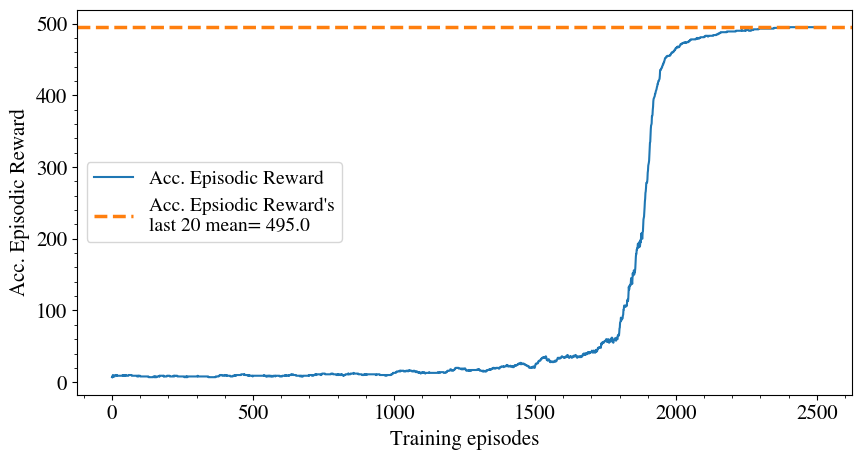

In [ ]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's\nlast 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.minorticks_on()
plt.xlabel("Training episodes")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
plt.legend(fontsize=14)
plt.show()

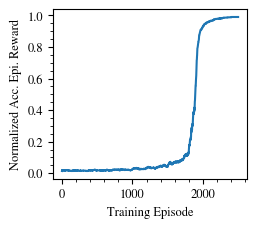

In [ ]:
# Episodes versus Avg. Rewards

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
#plt.xticks(np.arange(0, 2501, 500))
#plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.minorticks_on()
#plt.savefig(path+"Cartpole_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
state = 0
action = 0
next_state = 0
next_action = 0

In [ ]:
print("Avg. Epsiodic Reward's last 5 epoch mean=")
print(np.array(avg_reward_list)[-5:].mean())

Avg. Epsiodic Reward's last 5 epoch mean=
495.0


**Test Ideal Env**

In [ ]:
observation = env.reset()
total_episodes_test = 100
best_score = -1000
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
#env.ideal_env = False
#env.DCMotorModel.Kp = 0.0
#env.DCMotorModel.Ki = 0.0
#env.DCMotorModel.Kd = 0.0
#env.DCMotorModel.Kr = 1.0
#env.DCMotorModel.Kw = 0.0

## for training with desined PID ctrl:
#env.ideal_env = False
#env.DCMotorModel.Kp = 4.3
#env.DCMotorModel.Ki = 1.0
#env.DCMotorModel.Kd = 10**(-6)
#env.DCMotorModel.Kr = 0.7
#env.DCMotorModel.Kw = 1.0

In [ ]:
# To store reward history of each episode
ep_reward_list_test = []
# To store average reward history of last few episodes
avg_reward_list_test = []

ep_abs_error_action_list_test = []
avg_ep_abs_error_action_list_test = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

num_success = 0
print('Test')
for ep in range(total_episodes_test):
    observation = env.reset()
    save_observation_temp = [observation]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_sp_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]
    done=False
    t=0
    episodic_reward = 0
    while not done and t<steps_per_episode_goal:
        # using our observation, choose an action and take it in the environment
        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        episodic_reward += reward
        observation = observation_new
        save_observation_temp.append(observation)
        save_wanted_torque_temp.append(torque_wanted)
        save_actual_torque_temp.append(torque_actual)
        save_sp_torque_temp.append(env.MPC.y_spf)
        save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
        save_ctrl_voltage_temp.append(0.0)
        t+=1

    # get best score and update save data
    #save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Pole fell: {done}")
    if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward
    ep_reward_list_test.append(episodic_reward)
    num_success+= 0 + (not done)

Test
Test
Episode: 0; Acc. Reward: 492.2; Pole fell: False
Episode: 1; Acc. Reward: 491.1; Pole fell: False
Episode: 2; Acc. Reward: 486.8; Pole fell: False
Episode: 3; Acc. Reward: 486.2; Pole fell: False
Episode: 4; Acc. Reward: 486.2; Pole fell: False
Episode: 5; Acc. Reward: 490.4; Pole fell: False
Episode: 6; Acc. Reward: 493.6; Pole fell: False
Episode: 7; Acc. Reward: 493.2; Pole fell: False
Episode: 8; Acc. Reward: 488.8; Pole fell: False
Episode: 9; Acc. Reward: 495.0; Pole fell: False
Episode: 10; Acc. Reward: 492.5; Pole fell: False
Episode: 11; Acc. Reward: 494.3; Pole fell: False
Episode: 12; Acc. Reward: 491.9; Pole fell: False
Episode: 13; Acc. Reward: 488.9; Pole fell: False
Episode: 14; Acc. Reward: 487.9; Pole fell: False
Episode: 15; Acc. Reward: 490.8; Pole fell: False
Episode: 16; Acc. Reward: 485.8; Pole fell: False
Episode: 17; Acc. Reward: 489.0; Pole fell: False
Episode: 18; Acc. Reward: 489.4; Pole fell: False
Episode: 19; Acc. Reward: 491.7; Pole fell: False


In [ ]:
score = num_success/total_episodes_test*100
print(f"score=({num_success} successes)/({total_episodes_test} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


In [ ]:
print("Acc. Episodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())
print(f"Normalized mean= {unnorm_to_norm(np.array(ep_reward_list_test).mean()):.3e}")
print(f"Normalized std = {unnorm_to_norm(np.array(ep_reward_list_test).std()):.3e}")

Acc. Episodic Reward's mean=
491.13087984708733
Normalized mean= 9.823e-01
Normalized std = 6.322e-03


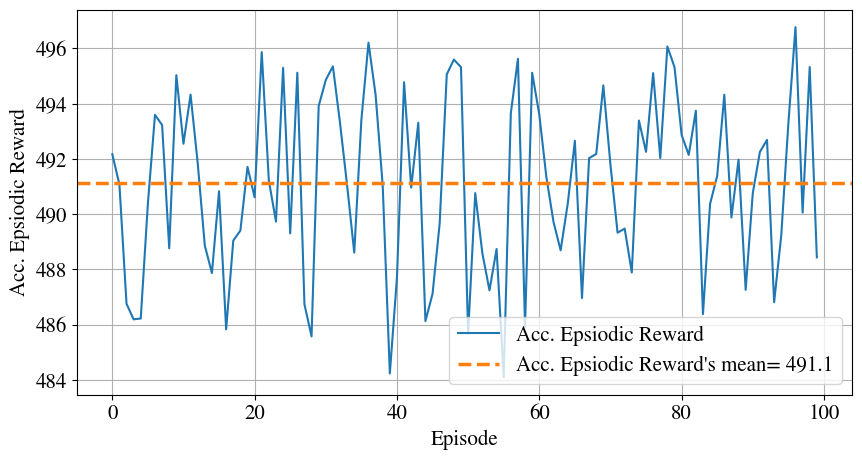

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(ep_reward_list_test, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list_test).mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's mean= "+f"{np.array(ep_reward_list_test).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


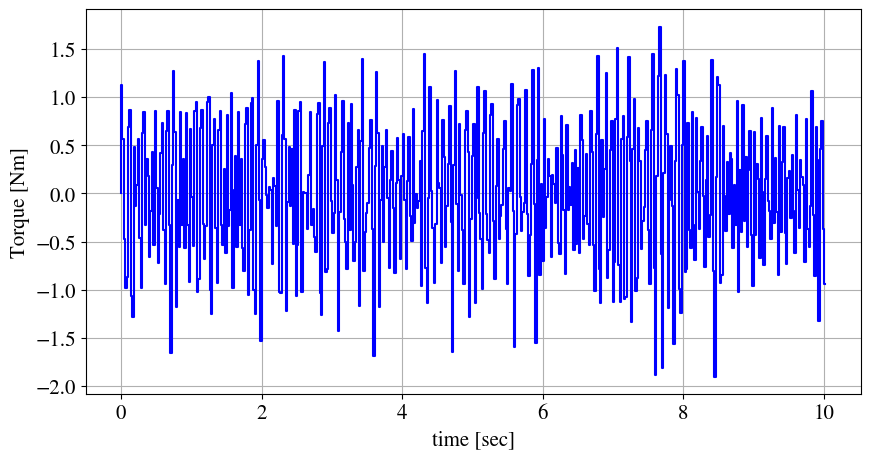

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
  print("for t≥"+str(2*dt)+",n≥2:")
  print("mean=", f'{e_ry[2:].mean():.4e}')
  print("std=", f'{e_ry[2:].std():.4e}')
  print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
  print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

In [ ]:
print(len(position))

501


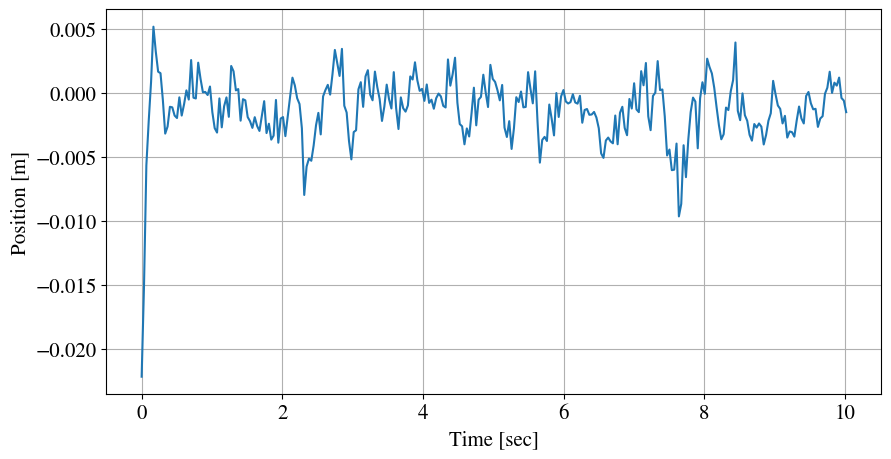

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

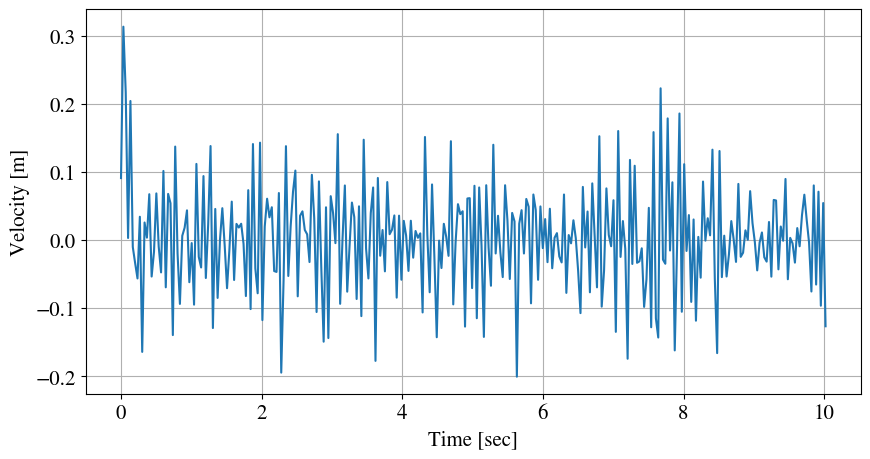

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

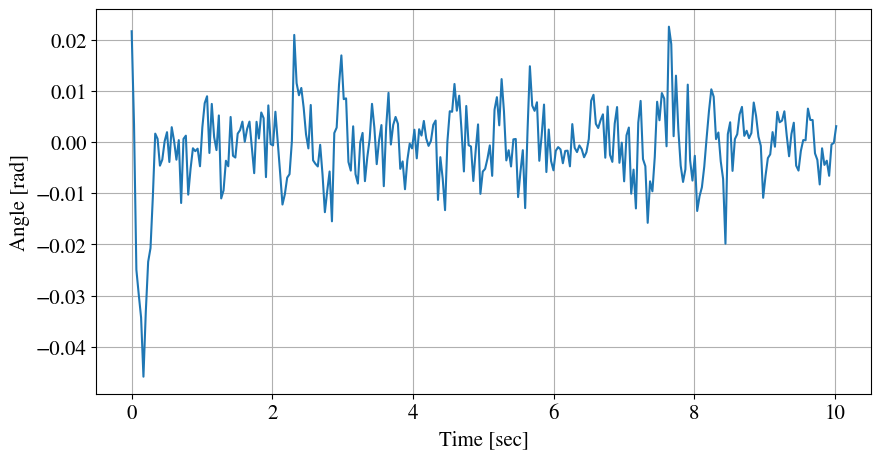

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

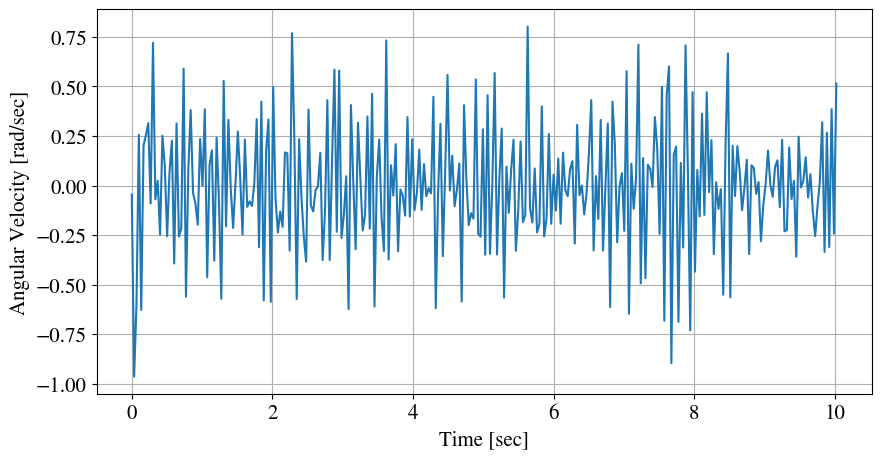

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Actual Env Ctrl**

In [ ]:
env = CartPole()
observation = env.reset()
total_episodes_test = 100
best_score = -1000
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
#env.ideal_env = True


## for training with desined MPC ctrl:
env.ideal_env = False

In [ ]:
# To store reward history of each episode
ep_reward_list_test = []
# To store average reward history of last few episodes
avg_reward_list_test = []

ep_abs_error_action_list_test = []
avg_ep_abs_error_action_list_test = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

num_success = 0
print('Test')
for ep in range(total_episodes_test):
    observation = env.reset()
    save_observation_temp = [observation]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_sp_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]
    done=False
    t=0
    episodic_reward = 0
    while not done and t<steps_per_episode_goal:
        # using our observation, choose an action and take it in the environment
        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        episodic_reward += reward
        observation = observation_new
        save_observation_temp.append(observation)
        save_wanted_torque_temp.append(torque_wanted)
        save_actual_torque_temp.append(torque_actual)
        save_sp_torque_temp.append(env.MPC.y_spf)
        save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
        save_ctrl_voltage_temp.append(0.0)
        t+=1

    # get best score and update save data
    #save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Pole fell: {done}")
    if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward
    ep_reward_list_test.append(episodic_reward)
    num_success+= 0 + (not done)

Test
Test
Episode: 0; Acc. Reward: 494.6; Pole fell: False
Episode: 1; Acc. Reward: 490.6; Pole fell: False
Episode: 2; Acc. Reward: 487.1; Pole fell: False
Episode: 3; Acc. Reward: 495.8; Pole fell: False
Episode: 4; Acc. Reward: 494.1; Pole fell: False
Episode: 5; Acc. Reward: 489.3; Pole fell: False
Episode: 6; Acc. Reward: 489.9; Pole fell: False
Episode: 7; Acc. Reward: 495.2; Pole fell: False
Episode: 8; Acc. Reward: 492.1; Pole fell: False
Episode: 9; Acc. Reward: 495.9; Pole fell: False
Episode: 10; Acc. Reward: 487.9; Pole fell: False
Episode: 11; Acc. Reward: 495.0; Pole fell: False
Episode: 12; Acc. Reward: 486.4; Pole fell: False
Episode: 13; Acc. Reward: 491.7; Pole fell: False
Episode: 14; Acc. Reward: 486.4; Pole fell: False
Episode: 15; Acc. Reward: 488.6; Pole fell: False
Episode: 16; Acc. Reward: 496.1; Pole fell: False
Episode: 17; Acc. Reward: 491.5; Pole fell: False
Episode: 18; Acc. Reward: 495.5; Pole fell: False
Episode: 19; Acc. Reward: 495.9; Pole fell: False


In [ ]:
score = num_success/total_episodes_test*100
print(f"score=({num_success} successes)/({total_episodes_test} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


In [ ]:
print("Acc. Episodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())
print(f"Normalized mean= {unnorm_to_norm(np.array(ep_reward_list_test).mean()):.3e}")
print(f"Normalized std = {unnorm_to_norm(np.array(ep_reward_list_test).std()):.3e}")

Acc. Episodic Reward's mean=
491.12141620551193
Normalized mean= 9.822e-01
Normalized std = 7.233e-03


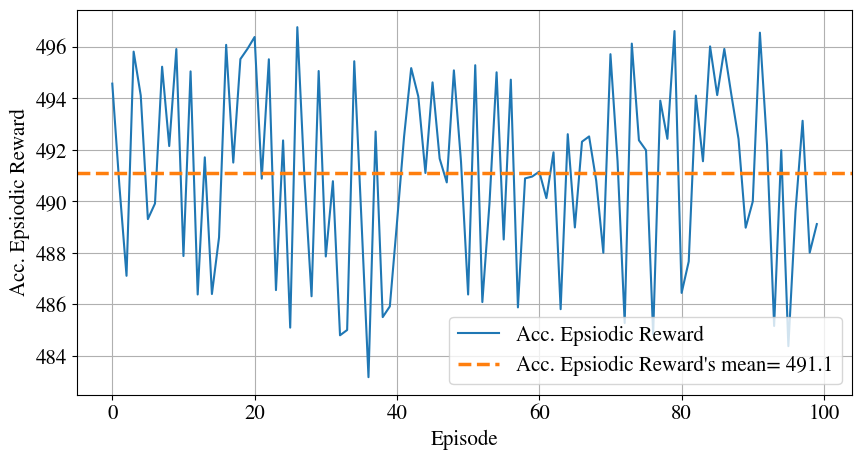

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(ep_reward_list_test, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list_test).mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's mean= "+f"{np.array(ep_reward_list_test).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


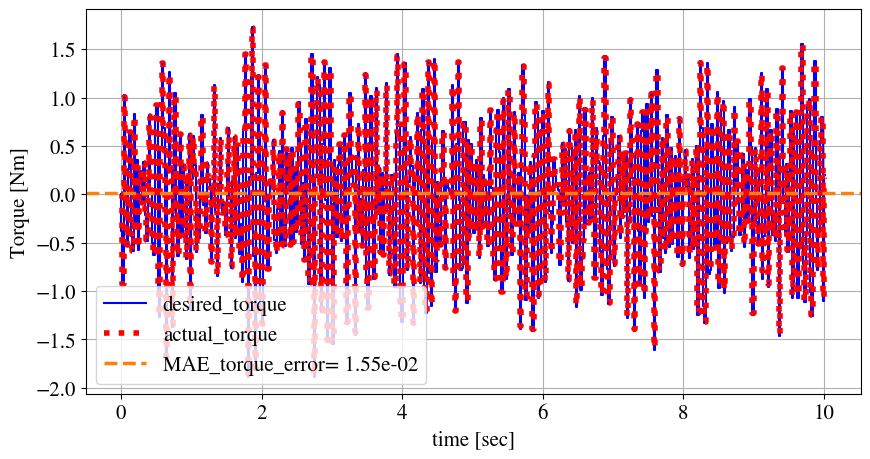

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
  print("for t≥"+str(2*dt)+",n≥2:")
  print("mean=", f'{e_ry[2:].mean():.4e}')
  print("std=", f'{e_ry[2:].std():.4e}')
  print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
  print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.04,n≥2:
mean= -1.8457e-03
std= 2.3695e-02
rms= 2.3767e-02
mae= 1.4844e-02


In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

In [ ]:
print(len(position))

501


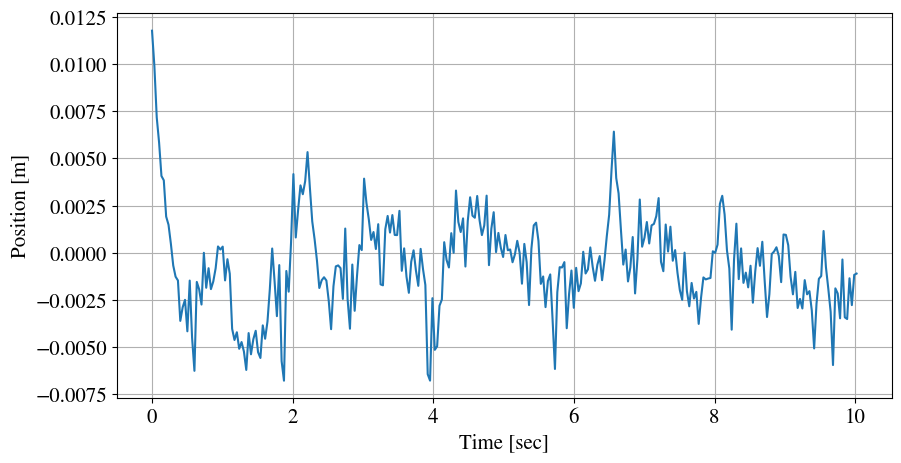

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

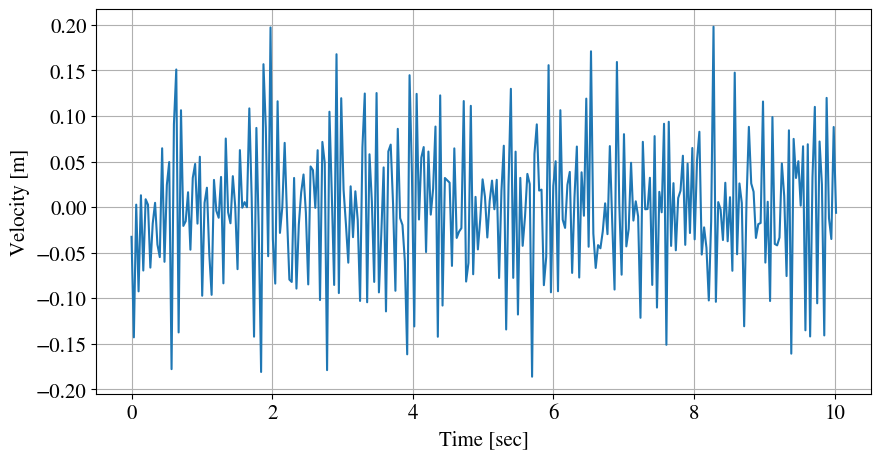

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

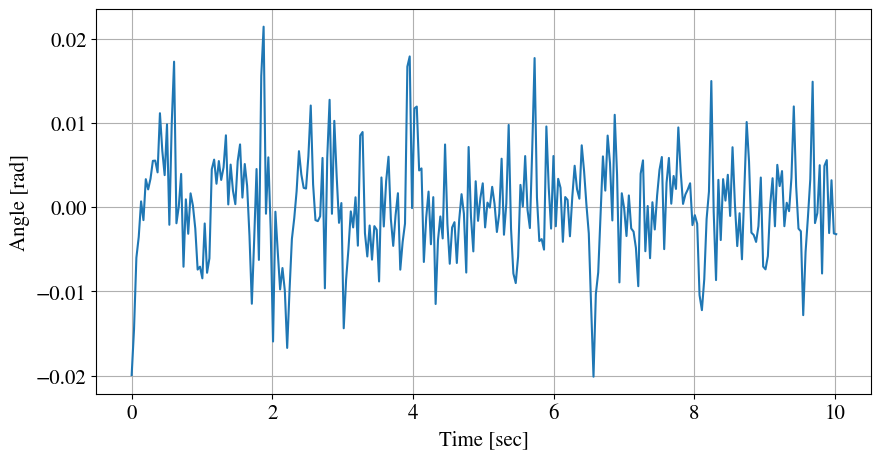

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

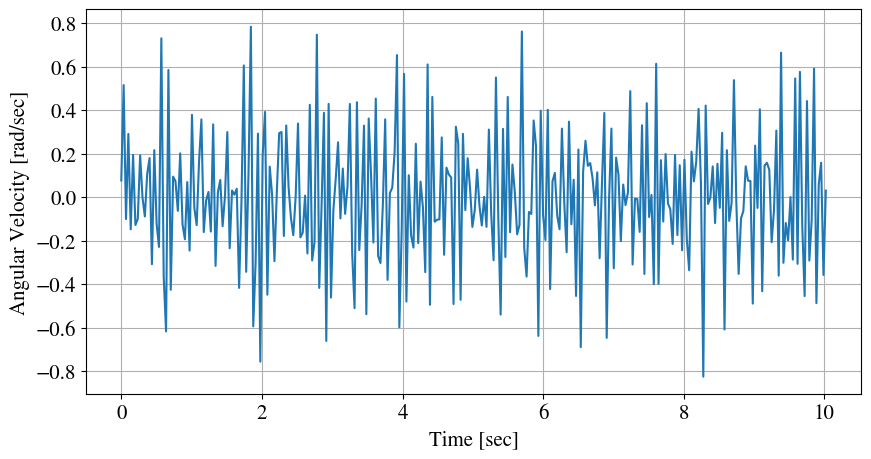

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Actual Env FF**

In [ ]:
observation = env.reset()
total_episodes_test = 100
best_score = -1000
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
#env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
env.ideal_env = False
#env.MPC.K_MPC=  np.array([[ 5.4295893,  -4.44155325]])
env.MPC.K_MPC = np.array([[ 1.0,  0.0]])
env.MPC.k_w = 0.0



In [ ]:
# To store reward history of each episode
ep_reward_list_test = []
# To store average reward history of last few episodes
avg_reward_list_test = []

ep_abs_error_action_list_test = []
avg_ep_abs_error_action_list_test = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

num_success = 0
print('Test')
for ep in range(total_episodes_test):
    observation = env.reset()
    save_observation_temp = [observation]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_sp_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]
    done=False
    t=0
    episodic_reward = 0
    while not done and t<steps_per_episode_goal:
        # using our observation, choose an action and take it in the environment
        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        episodic_reward += reward
        observation = observation_new
        save_observation_temp.append(observation)
        save_wanted_torque_temp.append(torque_wanted)
        save_actual_torque_temp.append(torque_actual)
        save_sp_torque_temp.append(env.MPC.y_spf)
        save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
        save_ctrl_voltage_temp.append(0.0)
        t+=1

    # get best score and update save data
    #save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Pole fell: {done}")
    if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward
    ep_reward_list_test.append(episodic_reward)
    num_success+= 0 + (not done)

Test
Test
Episode: 0; Acc. Reward: 67.9; Pole fell: True
Episode: 1; Acc. Reward: 189.8; Pole fell: True
Episode: 2; Acc. Reward: 150.9; Pole fell: True
Episode: 3; Acc. Reward: 146.5; Pole fell: True
Episode: 4; Acc. Reward: 336.4; Pole fell: True
Episode: 5; Acc. Reward: 222.0; Pole fell: True
Episode: 6; Acc. Reward: 30.3; Pole fell: True
Episode: 7; Acc. Reward: 226.7; Pole fell: True
Episode: 8; Acc. Reward: 113.2; Pole fell: True
Episode: 9; Acc. Reward: 132.7; Pole fell: True
Episode: 10; Acc. Reward: 160.8; Pole fell: True
Episode: 11; Acc. Reward: 130.8; Pole fell: True
Episode: 12; Acc. Reward: 120.7; Pole fell: True
Episode: 13; Acc. Reward: 137.4; Pole fell: True
Episode: 14; Acc. Reward: 281.0; Pole fell: True
Episode: 15; Acc. Reward: 153.0; Pole fell: True
Episode: 16; Acc. Reward: 69.7; Pole fell: True
Episode: 17; Acc. Reward: 21.3; Pole fell: True
Episode: 18; Acc. Reward: 127.3; Pole fell: True
Episode: 19; Acc. Reward: 221.0; Pole fell: True
Episode: 20; Acc. Reward

In [ ]:
env.MPC.K_MPC=K_MPC
env.MPC.k_w = 1.0

In [ ]:
score = num_success/total_episodes_test*100
print(f"score=({num_success} successes)/({total_episodes_test} episodes)*100={score:.1f}")

score=(3 successes)/(100 episodes)*100=3.0


In [ ]:
print("Acc. Episodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())
print(f"Normalized mean= {unnorm_to_norm(np.array(ep_reward_list_test).mean()):.3e}")
print(f"Normalized std = {unnorm_to_norm(np.array(ep_reward_list_test).std()):.3e}")

Acc. Episodic Reward's mean=
165.38514112201239
Normalized mean= 3.308e-01
Normalized std = 2.042e-01


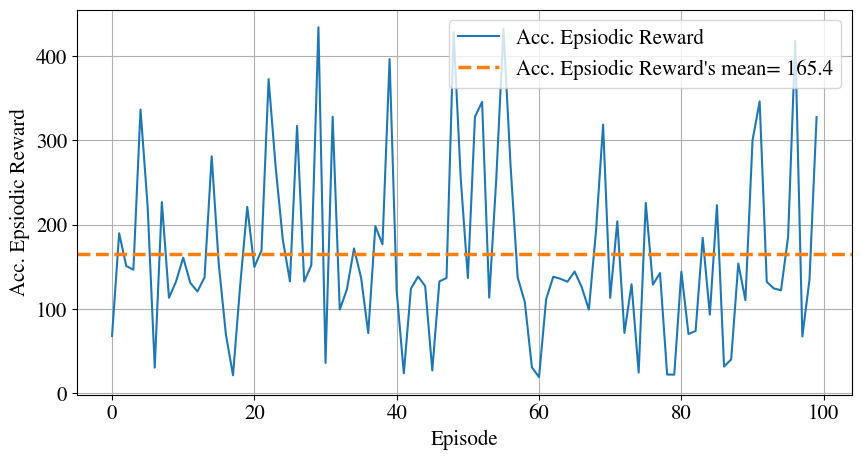

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(ep_reward_list_test, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list_test).mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's mean= "+f"{np.array(ep_reward_list_test).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Acc. Epsiodic Reward's mean=")
print(np.array(ep_reward_list_test).mean())

Acc. Epsiodic Reward's mean=
165.38514112201239


In [ ]:
dt=env.dt
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


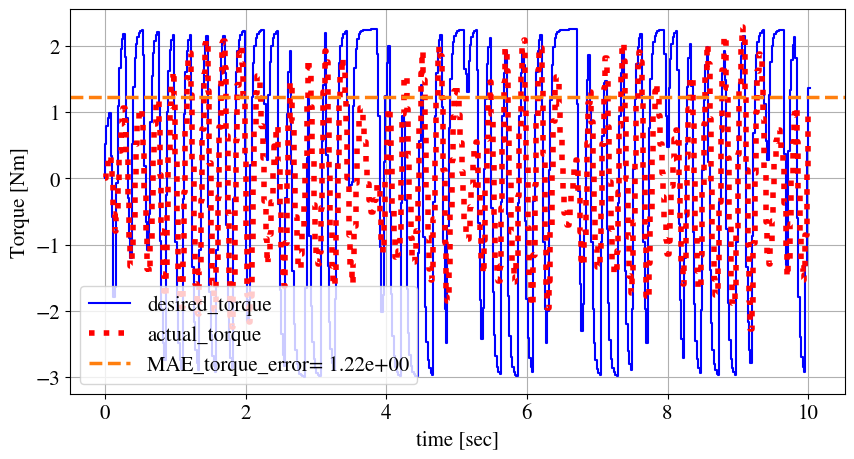

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
  print("for t≥"+str(2*dt)+",n≥2:")
  print("mean=", f'{e_ry[2:].mean():.4e}')
  print("std=", f'{e_ry[2:].std():.4e}')
  print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
  print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.04,n≥2:
mean= 7.6801e-02
std= 1.4312e+00
rms= 1.4332e+00
mae= 1.2287e+00


In [ ]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

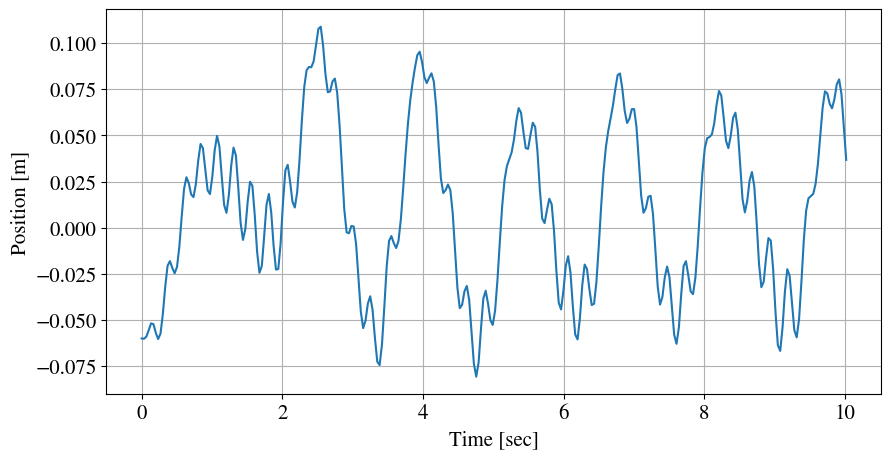

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [ ]:
print(len(position))


501


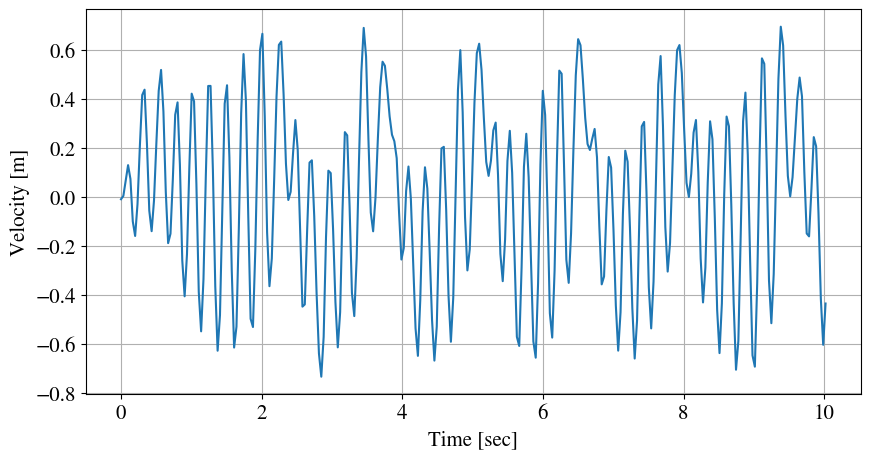

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

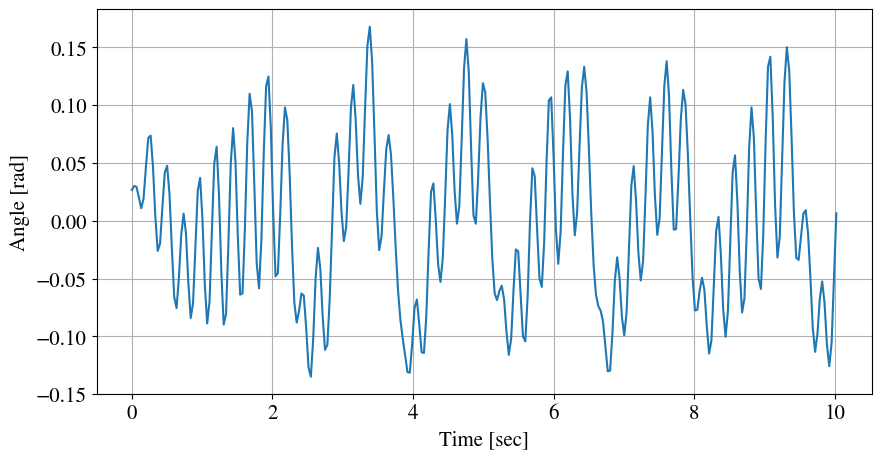

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

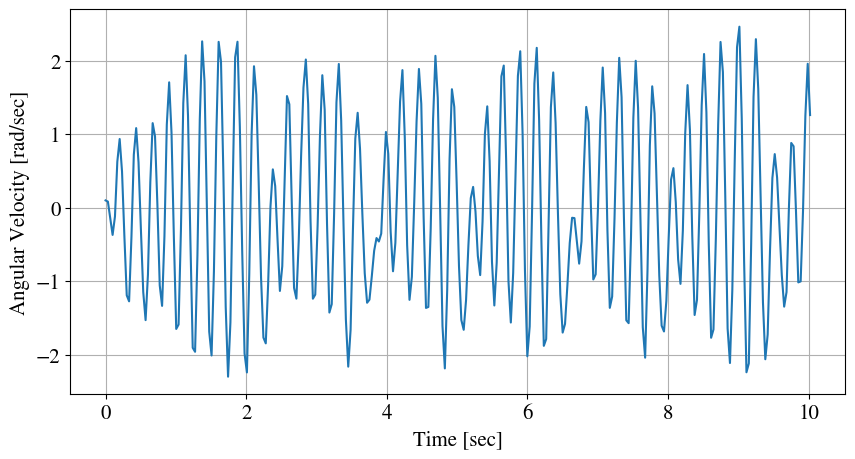

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()